In [2]:
LON_MIN = 52.753105528788296
LON_MAX = 61.123379687612506
LAT_MIN = 22.106445540189902
LAT_MAX = 27.762549166787664

In [3]:
import pandas as pd
import numpy as np

LOWER_T_VALUE = 6*2
LAT_CELLS = 300
LON_CELLS = 300

parquet = '../output/models/custom_ds_latent_size_128a_fivo_adamw/logprob.parquet'

_ds = pd.read_parquet(parquet, columns=['log_prob'])
_ds.index.levels[0]
lat_lon_ds = pd.read_parquet('../new_data/ais_test_by_bins.parquet', columns=['latitude', 'longitude'])
lat_lon_ds.index.levels[0]
_ds = pd.merge(_ds, lat_lon_ds, how='inner', left_index=True, right_index=True)
del lat_lon_ds
_ds = _ds.reset_index()
_ds = _ds.set_index('latitude')
_ds = _ds.set_index('longitude', append=True)
# higher than a timestamp
_ds = _ds[_ds['t']>= LOWER_T_VALUE]
_ds = _ds.drop(['t', 'track_id'], axis=1)
quantile=1.64
_ds = _ds[_ds.groupby(level=[0,1], sort=False)['log_prob'].transform(lambda ds: ( ds - ds.mean()) <= quantile * ds.std())]
_ds = _ds.groupby(level=[0,1]).agg(['mean', 'std', 'count'])


names = ['mean', 'std']
arrays = [pd.DataFrame(np.full((LAT_CELLS,LON_CELLS), np.nan)) for _ in range(2)]
dsl =  _ds.reset_index().pivot(index='longitude', columns='latitude')
for name, array in zip(names, arrays):
    dslc = dsl[('log_prob', name)]
    array.loc[dslc.index, dslc.columns] = dslc
arrays = [a.values for a in arrays]

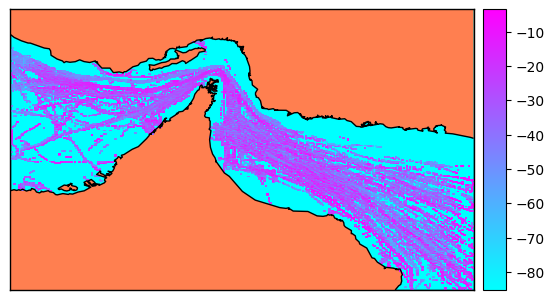

In [8]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt



# Create a Basemap instance with a specific projection and bounding coordinates
map = Basemap(
   projection='gall', llcrnrlat=LAT_MIN, urcrnrlat=LAT_MAX,
   llcrnrlon=LON_MIN, urcrnrlon=LON_MAX, resolution='i')
# map = Basemap(
#    projection='lcc',  llcrnrlat=LAT_MIN, urcrnrlat=LAT_MAX,
#    llcrnrlon=LON_MIN, urcrnrlon=LON_MAX, lat_1=LAT_MIN, lat_2=LAT_MAX,
#    lat_0=(LAT_MAX+LAT_MIN)/2, lon_0=LON_MIN, resolution='i')

# Draw coastlines and countries
map.drawcoastlines()
map.drawmapboundary(fill_color='aqua') 
# fill continents, set lake color same as ocean color. 
map.fillcontinents(color='coral',lake_color='aqua')

_, _, x, y = map.makegrid(300,300, returnxy=True)
# cs = map.imshow(arrays[0].T)
map.pcolor(x,y, arrays[0].T, cmap='cool')
map.colorbar()
# map.drawmapscale(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX, 500)
# Show the map
plt.show()

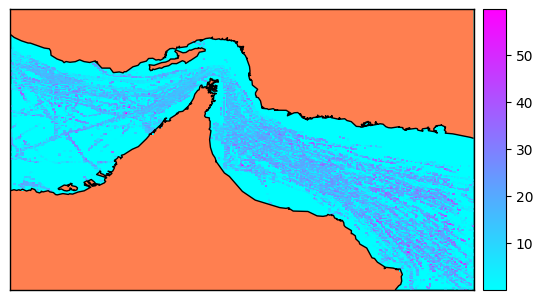

In [46]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt



# Create a Basemap instance with a specific projection and bounding coordinates
map = Basemap(
   projection='gall', llcrnrlat=LAT_MIN, urcrnrlat=LAT_MAX,
   llcrnrlon=LON_MIN, urcrnrlon=LON_MAX, resolution='i')

# Draw coastlines and countries
map.drawcoastlines()
map.drawmapboundary(fill_color='aqua') 
# fill continents, set lake color same as ocean color. 
map.fillcontinents(color='coral',lake_color='aqua')

_, _, x, y = map.makegrid(300,300, returnxy=True)
# cs = map.imshow(arrays[0].T)
map.pcolor(x,y, arrays[1].T, cmap='cool')
map.colorbar()
# map.drawmapscale(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX, 500)
# Show the map
plt.show()

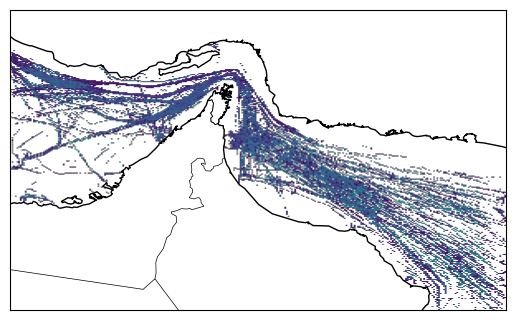

In [24]:
# Create a Basemap instance with a specific projection and bounding coordinates
map = Basemap(
   projection='gall', llcrnrlat=LAT_MIN, urcrnrlat=LAT_MAX,
   llcrnrlon=LON_MIN, urcrnrlon=LON_MAX, resolution='i')

# Draw coastlines and countries
map.drawcoastlines()
map.drawcountries()

map.imshow(arrays[1].T)
# Show the map
plt.show()

In [ ]:

FIG_DPI = 150
import scipy.ndimage as ndimage
def gaussian_filter_with_nan(U,sigma):
    """
    Apply Gaussian filter when the data contain NaN
    INPUT:
        U           : a 2-D array (matrix)
        sigma       : std for the Gaussian kernel
    OUTPUT:
        Z           : filtered matrix
    """
    V=U.copy()
    V[np.isnan(U)]=0
    VV= ndimage.gaussian_filter(V,sigma=sigma)

    W=0*U.copy()+1
    W[np.isnan(U)]=0
    WW= ndimage.gaussian_filter(W,sigma=sigma)
    Z=VV/WW
    return(Z)


def show_logprob_map(m_map_logprob_mean, m_map_logprob_std, save_dir, 
                     logprob_mean_min = -10.0, logprob_std_max = 5.0,
                     d_scale = 10, inter_method = "hanning",
                     fig_w = 960, fig_h = 960,
                    ):
    """
    Show the map of the mean and the std of the logprob in each cell.
    INPUT:
        m_map_logprob_mean   : a 2-D array (matrix)
        m_map_logprob_std    : a 2-D array (matrix)
        save_dir             : directory to save the images
    """    
    # Truncate
    m_map_logprob_mean[m_map_logprob_mean<logprob_mean_min] = logprob_mean_min
    m_map_logprob_std[m_map_logprob_std>logprob_std_max] = logprob_std_max
    
    # Improve the resolution
    n_rows, n_cols = m_map_logprob_mean.shape
    m_mean = np.zeros((n_rows*d_scale,n_cols*d_scale))
    m_std = np.zeros((n_rows*d_scale,n_cols*d_scale))
    for i_row in range(m_map_logprob_mean.shape[0]):
        for i_col in range(m_map_logprob_mean.shape[1]):
            m_mean[d_scale*i_row:d_scale*(i_row+1),d_scale*i_col:d_scale*(i_col+1)] = m_map_logprob_mean[i_row,i_col]
            m_std[d_scale*i_row:d_scale*(i_row+1),d_scale*i_col:d_scale*(i_col+1)] = m_map_logprob_std[i_row,i_col]

    # Gaussian filter (with NaN)
    m_nan_idx = np.isnan(m_mean)
    m_mean = gaussian_filter_with_nan(m_mean, sigma=4.0)
    m_mean[m_nan_idx] = np.nan
    m_std = gaussian_filter_with_nan(m_std, sigma=4.0)
    m_nan_idx = np.isnan(m_std)
    m_std[m_nan_idx] = np.nan

    plt.figure(figsize=(fig_w/FIG_DPI, fig_h/FIG_DPI), dpi=FIG_DPI)
    # plt.subplot(1,2,1)
    im = plt.imshow(np.flipud(m_mean),interpolation=inter_method)
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir,"logprob_mean_map.png"))
    plt.close()

    plt.figure(figsize=(fig_w/FIG_DPI, fig_h/FIG_DPI), dpi=FIG_DPI)
    # plt.subplot(1,2,2)
    im = plt.imshow(np.flipud(m_std),interpolation=inter_method)
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir,"logprob_std_map.png"))
    plt.close()


In [5]:
from migration.heatmap import show_logprob_map

LAT_RANGE = 300 - 0
LON_RANGE = 300 - 0

FIG_W = 960
FIG_H = int(FIG_W*LAT_RANGE/LON_RANGE)

LOGPROB_MEAN_MIN = -10.0
LOGPROB_STD_MAX = 5


show_logprob_map(arrays[0], arrays[1],
                 '.',
                 logprob_mean_min = LOGPROB_MEAN_MIN,
                           logprob_std_max = LOGPROB_STD_MAX,
                           fig_w = FIG_W, fig_h = FIG_H,
                 )

/home/eouser/aizuzquiza/GeoTrackNet/migration/packages/v2/src/migration/heatmap.py:59: RuntimeWarning: invalid value encountered in divide
  Z=VV/WW


In [107]:
a = np.zeros((3,3), dtype=np.float32)

In [108]:
a[:] = np.nan

In [109]:
a

array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]], dtype=float32)